# HvMF Data Visualization on Unit Hyperboloid

This notebook visualizes the Hyperbolic von Mises-Fisher (HvMF) sample data generated from the R script to verify that:
1. All points lie correctly on the unit hyperboloid surface
2. Samples show proper concentration around the mean direction μ
3. The data generation process is working as expected

The hyperboloid constraint is: **-x₁² + x₂² + x₃² = -1**

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from pathlib import Path

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")
print("Current working directory:", Path.cwd())

Libraries imported successfully!
Current working directory: /Users/Diego/Desktop/Codigo/goodness_of_fit_metric_spaces


## Load and Validate HvMF Sample Data

Load the CSV data generated by our R script and perform initial validation.

In [83]:
# Load the CSV data generated by R script
data_file = "hvmf_visualization_data.csv"
df = pd.read_csv(data_file)

print("Data loaded successfully!")
print(f"Data shape: {df.shape}")
print(f"Data columns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head())

# Separate mu (reference point) and samples
mu_data = df[df['type'] == 'mu']
sample_data = df[df['type'] == 'sample']

print(f"\nReference point μ: {mu_data.iloc[0][['V1', 'V2', 'V3']].values}")
print(f"Number of samples: {len(sample_data)}")

# Extract coordinates
mu_coords = mu_data[['V1', 'V2', 'V3']].values[0]
sample_coords = sample_data[['V1', 'V2', 'V3']].values

print(f"\nMu coordinates: {mu_coords}")
print(f"Sample coordinates shape: {sample_coords.shape}")

Data loaded successfully!
Data shape: (201, 4)
Data columns: ['V1', 'V2', 'V3', 'type']

Data types:
V1      float64
V2      float64
V3      float64
type     object
dtype: object

First few rows:
         V1        V2        V3    type
0  1.414214  0.707107  0.707107      mu
1  1.612183  0.824902  0.958473  sample
2  1.614993  0.948264  0.842021  sample
3  1.415455  0.802243  0.599932  sample
4  1.327304  0.763246  0.423309  sample

Reference point μ: [1.4142135623731 0.707106781186547 0.707106781186547]
Number of samples: 200

Mu coordinates: [1.41421356 0.70710678 0.70710678]
Sample coordinates shape: (200, 3)


## Hyperboloid Constraint Validation

Verify that all points satisfy the unit hyperboloid constraint: **-x₁² + x₂² + x₃² = -1**

In [84]:
# Define the hyperboloid constraint function
def hyperboloid_constraint(points):
    """Calculate -x1^2 + x2^2 + x3^2 for hyperboloid constraint (should be -1)"""
    return -points[:, 0]**2 + points[:, 1]**2 + points[:, 2]**2

# Check constraint for mu
mu_constraint = hyperboloid_constraint(mu_coords.reshape(1, -1))[0]
print(f"μ constraint value: {mu_constraint:.10f} (should be -1)")

# Check constraint for all samples
sample_constraints = hyperboloid_constraint(sample_coords)
print(f"\nSample constraint statistics:")
print(f"  Mean: {np.mean(sample_constraints):.10f}")
print(f"  Std:  {np.std(sample_constraints):.2e}")
print(f"  Min:  {np.min(sample_constraints):.10f}")
print(f"  Max:  {np.max(sample_constraints):.10f}")
print(f"  Max deviation from -1: {np.max(np.abs(sample_constraints + 1)):.2e}")

# Check if all constraints are satisfied (within numerical precision)
tolerance = 1e-10
constraint_satisfied = np.all(np.abs(sample_constraints + 1) < tolerance)
print(f"\nAll constraints satisfied (tolerance {tolerance}): {constraint_satisfied}")

if not constraint_satisfied:
    violations = np.sum(np.abs(sample_constraints + 1) >= tolerance)
    print(f"Number of constraint violations: {violations}/{len(sample_constraints)}")
else:
    print("✓ All points lie exactly on the hyperboloid surface!")

μ constraint value: -1.0000000000 (should be -1)

Sample constraint statistics:
  Mean: -1.0000000000
  Std:  9.21e-15
  Min:  -1.0000000000
  Max:  -1.0000000000
  Max deviation from -1: 2.80e-14

All constraints satisfied (tolerance 1e-10): True
✓ All points lie exactly on the hyperboloid surface!


## Hyperboloid Visualization in Your Requested Format

Creating a plot that matches your specific format with wireframe hyperboloid and curve visualization.

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_39464/2093325025.py:38: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


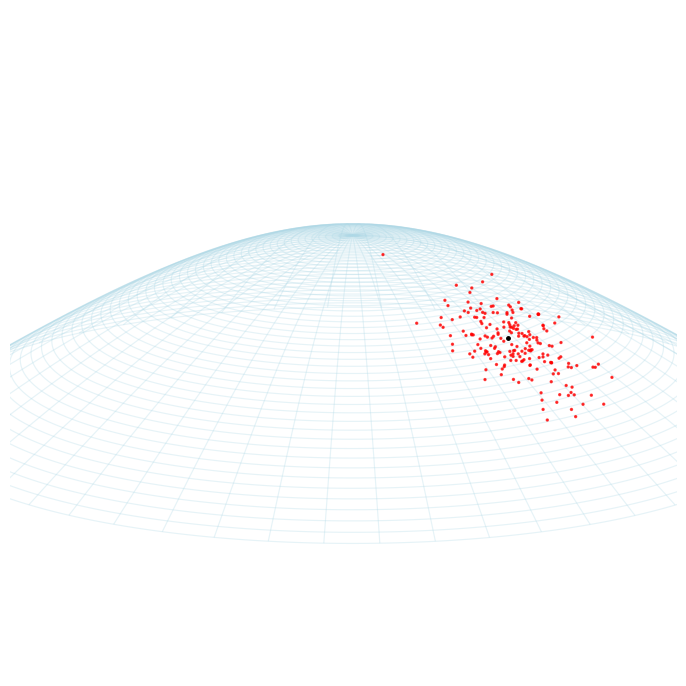

Hyperboloid visualization created and saved!


In [85]:
# Create hyperboloid plot in your requested format
import os

# For hyperboloid
u = np.linspace(0, 1.5, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)


fig = plt.figure(constrained_layout=True)
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)

# Plot wireframe hyperboloid
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder=0, linewidth=0.85)

# Use your sample data to create colored groups
cmap = plt.cm.rainbow

    
ax.plot(np.sqrt(2), 1/np.sqrt(2), 1/np.sqrt(2), color='black', marker='.', lw=0, markersize=5, zorder=1)

scatter_samples = ax.scatter(sample_coords[:, 0], sample_coords[:, 1], sample_coords[:, 2], 
                             c='red', s=2, alpha=0.7, label='HvMF Samples')
# Set plot properties to match your format
ax.set_axis_off()
ax.set_ylim(-1, 1)
ax.view_init(elev=3030, azim=0, roll=0)
ax.grid(False)

# Get legend handles and labels
h, l = ax.get_legend_handles_labels()
fig.tight_layout()

# Save the plot
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, 'hvmf_hyperboloid_visualization.png'), 
            bbox_inches='tight', dpi=200, format='png', transparent=True)

plt.show()

print("Hyperboloid visualization created and saved!")

## 10 Samples Visualization - Each Sample in Different Color

Load the 10 samples data and create a plot where each of the 10 simulations (of size 200) is shown in a different color.

10 Samples Data loaded successfully!
Data shape: (2002, 5)
Unique types: ['mu' 'omega1' 'sample_1' 'sample_2' 'sample_3' 'sample_4' 'sample_5'
 'sample_6' 'sample_7' 'sample_8' 'sample_9' 'sample_10']
Simulations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of samples per simulation: 200
Total samples: 2000
μ coordinates: [1.41421356 0.70710678 0.70710678]
ω1 coordinates: [1.41421356 0.70710678 0.70710678]


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_39464/4288978705.py:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


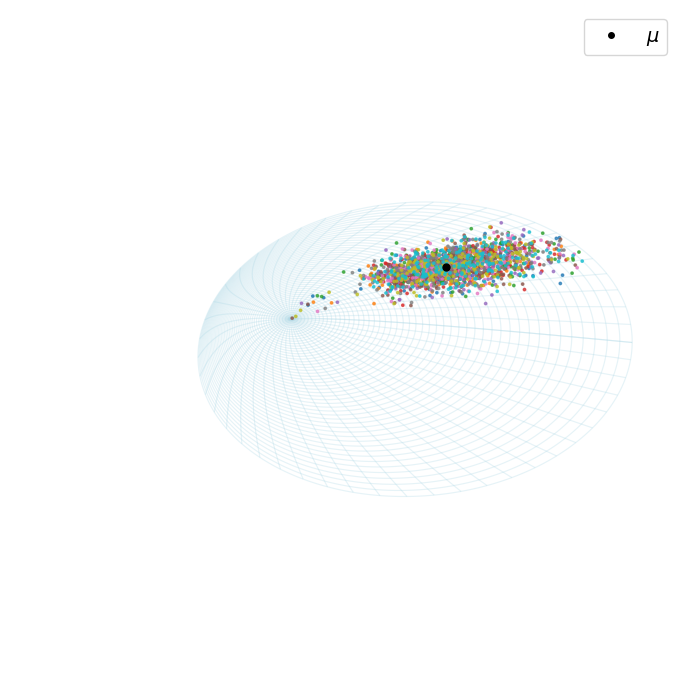

\n10 samples visualization created!
Each of the 10 simulations (200 samples each) shown in different colors
Total points plotted: 2000 samples + 1 μ point
Plot saved as: output/hvmf_10_samples_colored.png


In [113]:
# Load the 10 samples data
ten_samples_file = "hvmf_10_samples_data.csv"
df_10 = pd.read_csv(ten_samples_file)

print("10 Samples Data loaded successfully!")
print(f"Data shape: {df_10.shape}")
print(f"Unique types: {df_10['type'].unique()}")
print(f"Simulations: {sorted(df_10['simulation'].unique())}")

# Separate different types
mu_data_10 = df_10[df_10['type'] == 'mu']
omega1_data = df_10[df_10['type'] == 'omega1']
samples_data_10 = df_10[df_10['type'].str.startswith('sample_')]

print(f"Number of samples per simulation: {len(samples_data_10) // 10}")
print(f"Total samples: {len(samples_data_10)}")

# Extract coordinates
mu_coords_10 = mu_data_10[['V1', 'V2', 'V3']].values[0]
omega1_coords = omega1_data[['V1', 'V2', 'V3']].values[0]

print(f"μ coordinates: {mu_coords_10}")
print(f"ω1 coordinates: {omega1_coords}")

# Create hyperboloid plot with 10 different colored samples
# For hyperboloid
u = np.linspace(0, 1.22, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

fig = plt.figure(constrained_layout=True)
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)

# Plot wireframe hyperboloid
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder=0, linewidth=0.85)

# Plot μ (mean direction) as black dot
ax.plot(mu_coords_10[0], mu_coords_10[1], mu_coords_10[2], color='black', marker='.', lw=0, markersize=8, zorder=1, label=r'$\mu$')

# Create colormap for 10 different colors
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # tab10 gives distinct colors for up to 10 categories

# Plot each simulation in a different color
for sim_id in range(1, 11):
    sim_data = samples_data_10[samples_data_10['simulation'] == sim_id]
    sim_coords = sim_data[['V1', 'V2', 'V3']].values
    
    # Use distinct color for each simulation
    color = colors[sim_id - 1]
    
    ax.scatter(sim_coords[:, 0], sim_coords[:, 1], sim_coords[:, 2], 
              c=[color], s=3, alpha=0.7, zorder=1)

ax.plot(np.sqrt(2), 1/np.sqrt(2), 1/np.sqrt(2), color='black', marker='.', lw=0, markersize=10, zorder=1)


# Set plot properties to match your format
ax.set_axis_off()
ax.set_ylim(-1.5, 1.5)
ax.view_init(elev=5, azim=-20, roll=0)
ax.grid(False)

# Add legend for all 10 samples with smaller font
ax.legend(loc='upper right', fontsize=14, ncol=1)

# Get legend handles and labels
h, l = ax.get_legend_handles_labels()
fig.tight_layout()

# Save the plot
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, 'hvmf_10_samples_colored.png'), 
            bbox_inches='tight', dpi=200, format='png', transparent=True)

plt.show()

print("\\n10 samples visualization created!")
print(f"Each of the 10 simulations (200 samples each) shown in different colors")
print(f"Total points plotted: {len(samples_data_10)} samples + 1 μ point")
print("Plot saved as: output/hvmf_10_samples_colored.png")

## Fixed Visualization - All 10 Samples Visible

The issue was that only the first 5 samples had legend entries. All 10 samples were plotted, but samples 6-10 weren't labeled. Let's fix this:

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_39464/4264855521.py:47: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


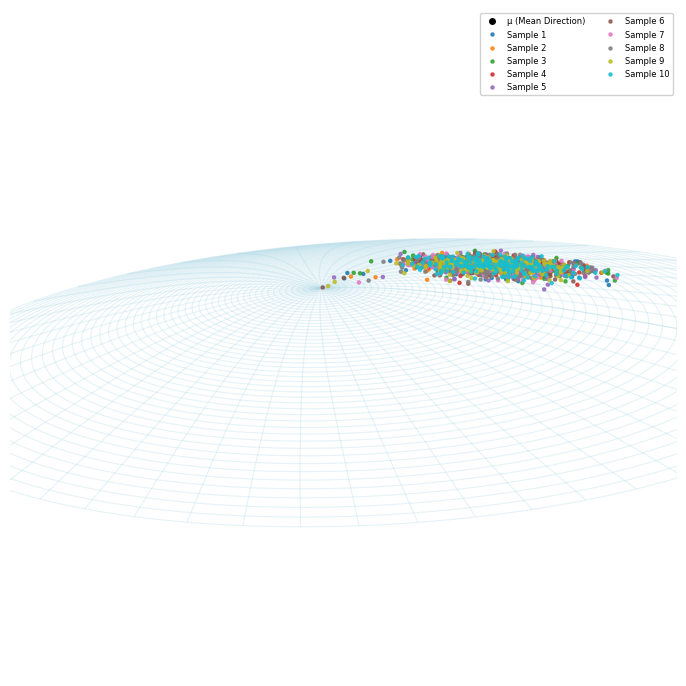

Fixed visualization created!
Now ALL 10 samples are labeled and visible in the legend
Each simulation has 200 samples in a unique color
Plot saved as: output/hvmf_10_samples_all_visible.png
\nSample verification:
  Sample 1: 200 points
  Sample 2: 200 points
  Sample 3: 200 points
  Sample 4: 200 points
  Sample 5: 200 points
  Sample 6: 200 points
  Sample 7: 200 points
  Sample 8: 200 points
  Sample 9: 200 points
  Sample 10: 200 points


In [88]:
# Create improved hyperboloid plot with ALL 10 samples clearly visible
# For hyperboloid
u = np.linspace(0, 1.5, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

fig = plt.figure(constrained_layout=True)
fig.set_size_inches(7, 7)
ax = plt.axes(projection='3d', computed_zorder=False)

# Plot wireframe hyperboloid
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder=0, linewidth=0.85)

# Plot μ (mean direction) as black dot
ax.plot(mu_coords_10[0], mu_coords_10[1], mu_coords_10[2], color='black', marker='.', lw=0, markersize=8, zorder=1, label='μ (Mean Direction)')

# Create colormap for 10 different colors
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # tab10 gives distinct colors for up to 10 categories

# Plot each simulation in a different color - ALL 10 WITH LABELS
for sim_id in range(1, 11):
    sim_data = samples_data_10[samples_data_10['simulation'] == sim_id]
    sim_coords = sim_data[['V1', 'V2', 'V3']].values
    
    # Use distinct color for each simulation
    color = colors[sim_id - 1]
    
    # Plot with larger points for better visibility
    ax.scatter(sim_coords[:, 0], sim_coords[:, 1], sim_coords[:, 2], 
              c=[color], s=5, alpha=0.8, 
              label=f'Sample {sim_id}', zorder=1)

# Set plot properties to match your format
ax.set_axis_off()
ax.set_ylim(-1, 1)
ax.view_init(elev=15, azim=-10, roll=0)
ax.grid(False)

# Add legend for ALL 10 samples with smaller font and 2 columns
ax.legend(loc='upper right', fontsize=6, ncol=2, framealpha=0.9)

fig.tight_layout()

# Save the plot
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, 'hvmf_10_samples_all_visible.png'), 
            bbox_inches='tight', dpi=200, format='png', transparent=True)

plt.show()

print("Fixed visualization created!")
print("Now ALL 10 samples are labeled and visible in the legend")
print(f"Each simulation has 200 samples in a unique color")
print("Plot saved as: output/hvmf_10_samples_all_visible.png")

# Let's also print the sample counts to verify
print("\\nSample verification:")
for sim_id in range(1, 11):
    sim_data = samples_data_10[samples_data_10['simulation'] == sim_id]
    print(f"  Sample {sim_id}: {len(sim_data)} points")